In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importing dataset
train = pd.read_csv(r"C:\Users\asus\Desktop\IDSS Major Project\Dataset\train.csv")
features = pd.read_csv(r"C:\Users\asus\Desktop\IDSS Major Project\Dataset\features.csv")
stores = pd.read_csv(r"C:\Users\asus\Desktop\IDSS Major Project\Dataset\stores.csv")

In [3]:
#Merging datasets
df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on= "Store", how = "left")
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [4]:
#Range of date in train and features datasets
print("Range of date in train:", train["Date"].min(), train["Date"].max())
print("Range of date in features:", features["Date"].min(), features["Date"].max())

Range of date in train: 2010-02-05 2012-10-26
Range of date in features: 2010-02-05 2013-07-26


In [5]:
#Shape of dataset
print("train shape:", train.shape)
print("features shape:", features.shape)
print("stores shape:", stores.shape)
print("Merged dataset shape:", df.shape)

train shape: (421570, 5)
features shape: (8190, 12)
stores shape: (45, 3)
Merged dataset shape: (421570, 16)


In [6]:
#Checking the duplicates
print("train duplicates:", train.duplicated().sum())
print("features duplicates:", features.duplicated().sum())
print("stores duplicates:", stores.duplicated().sum())
print("df duplicates:", df.duplicated().sum())

train duplicates: 0
features duplicates: 0
stores duplicates: 0
df duplicates: 0


In [7]:
#Checking null values
print("train nulls:", train.isnull().sum().sum())
print("features nulls:", features.isnull().sum().sum())
print("stores nulls:", stores.isnull().sum().sum())
print("df nulls:", df.isnull().sum().sum())

train nulls: 0
features nulls: 24040
stores nulls: 0
df nulls: 1422431


In [8]:
#Handling null values
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [9]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
df[markdown_cols].isnull().sum()

MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64

In [10]:
df[markdown_cols] = df[markdown_cols].fillna(0)
df[markdown_cols].isnull().sum()

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64

In [11]:
df["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

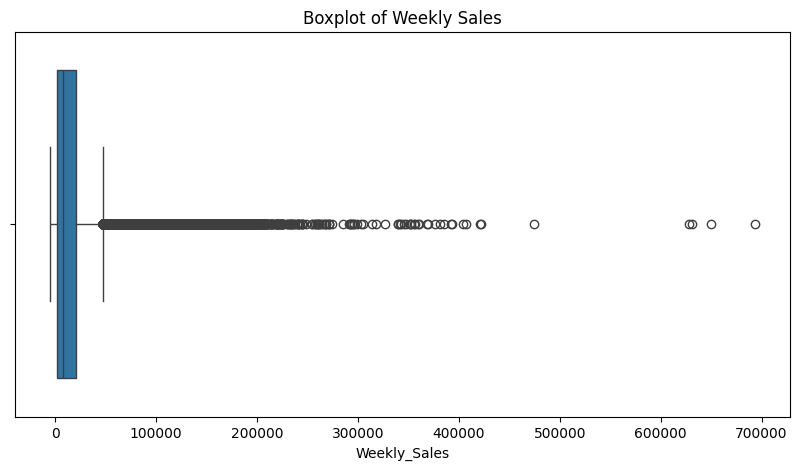

In [12]:
#Outliers in Weekly_Sales
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Weekly_Sales"])
plt.title("Boxplot of Weekly Sales")
plt.show()

In [13]:
#Outlier handling is not done as it is a time series data and outliers can be important for forecasting.
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound, "Upper Bound:", upper_bound)

Lower Bound: -25109.653749999998 Upper Bound: 47395.15625


In [14]:
#Handling negative Weekly_Sales and extreme outliers by clipping
upper_limit = df["Weekly_Sales"].quantile(0.99)
df["Weekly_Sales"] = df["Weekly_Sales"].clip(lower=0, upper=upper_limit)

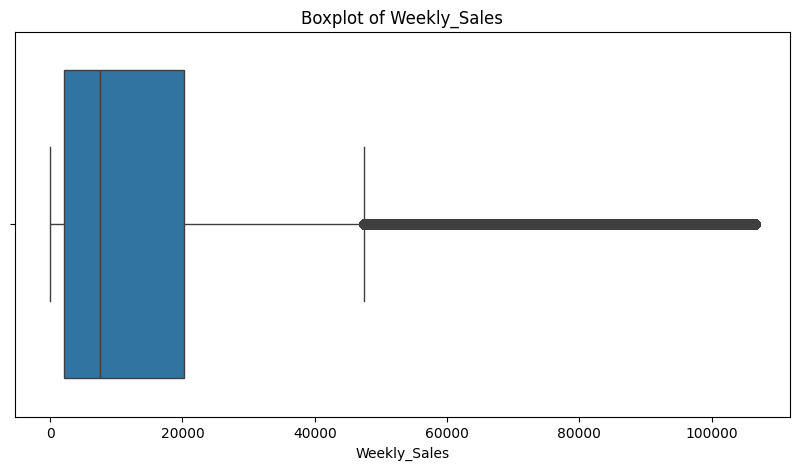

In [15]:
#Outliers in Weekly_Sales
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Weekly_Sales"])
plt.title("Boxplot of Weekly_Sales")
plt.show()

EDA

In [16]:
#Handling date column
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Quarter"] = df['Date'].dt.quarter
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Week"] = df["Week"].astype(int)
df["Day"] = df["Date"].dt.day
df['Is_Holiday_Season'] = df['Month'].isin([11, 12]).astype(int)
print(df[["Date", "Year", "Quarter", "Month", "Week", "Day", "Is_Holiday_Season"]].head())


        Date  Year  Quarter  Month  Week  Day  Is_Holiday_Season
0 2010-02-05  2010        1      2     5    5                  0
1 2010-02-12  2010        1      2     6   12                  0
2 2010-02-19  2010        1      2     7   19                  0
3 2010-02-26  2010        1      2     8   26                  0
4 2010-03-05  2010        1      3     9    5                  0


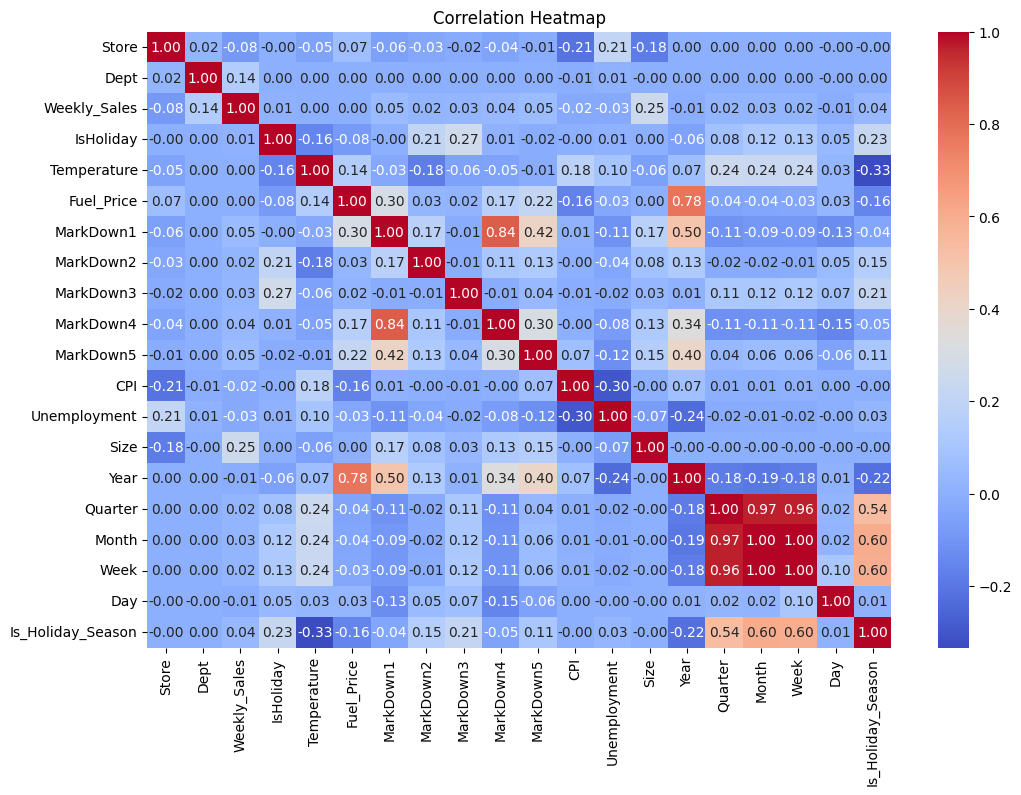

In [17]:
#Visualizing relationships and checking for multicollinearity
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
print(corr_matrix["Weekly_Sales"].sort_values(ascending = False))

Weekly_Sales         1.000000
Size                 0.252562
Dept                 0.142904
MarkDown5            0.052428
MarkDown1            0.049355
MarkDown4            0.039035
Is_Holiday_Season    0.037114
MarkDown3            0.029217
Month                0.025600
Week                 0.024711
MarkDown2            0.022002
Quarter              0.021156
IsHoliday            0.007922
Fuel_Price           0.001300
Temperature          0.000821
Day                 -0.007944
Year                -0.009344
CPI                 -0.022724
Unemployment        -0.025455
Store               -0.083814
Name: Weekly_Sales, dtype: float64


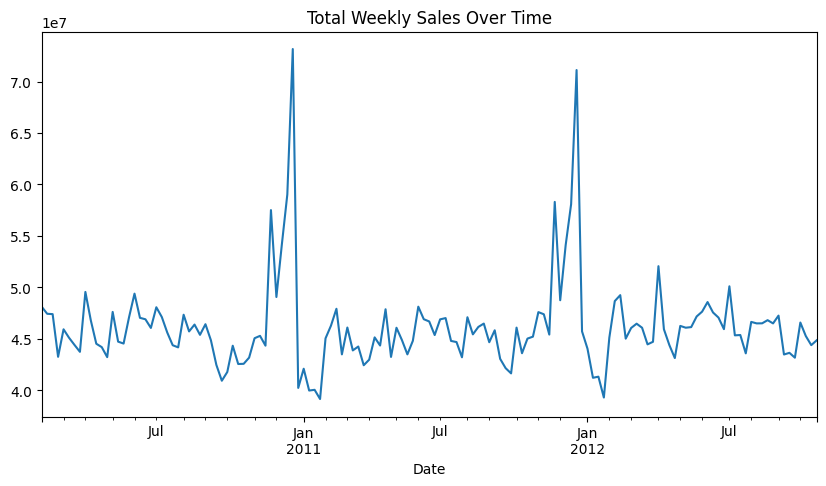

In [19]:
#Sales Trend
sales_trend = df.groupby("Date")["Weekly_Sales"].sum()
plt.figure(figsize=(10,5))
sales_trend.plot()
plt.title("Total Weekly Sales Over Time")
plt.show()

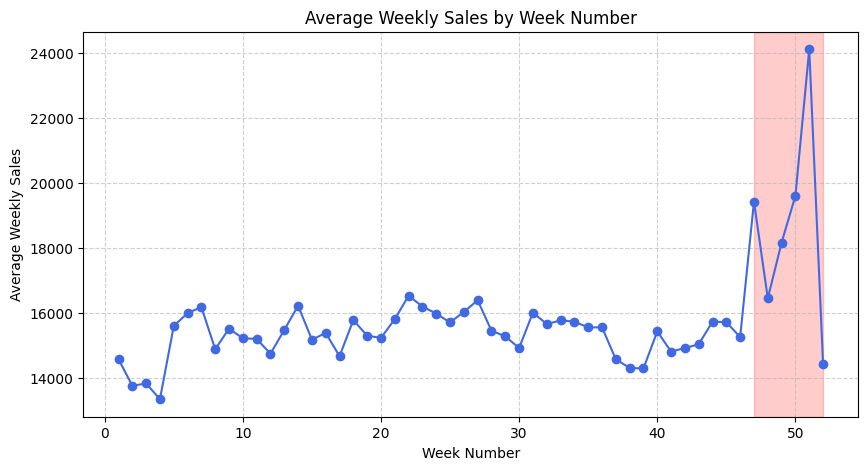

In [20]:
#Weekly sales average by week number
weekly_trend = df.groupby("Week")["Weekly_Sales"].mean()
plt.figure(figsize=(10,5))
plt.plot(weekly_trend.index, weekly_trend.values, marker="o", color='royalblue', label='Avg Sales')
plt.axvspan(47, 52, color='red', alpha=0.2, label='Holiday Season (Thanksgiving/Christmas)')
plt.grid(True,  linestyle='--', alpha=0.6)
plt.title("Average Weekly Sales by Week Number")
plt.xlabel("Week Number")
plt.ylabel("Average Weekly Sales")
plt.show()

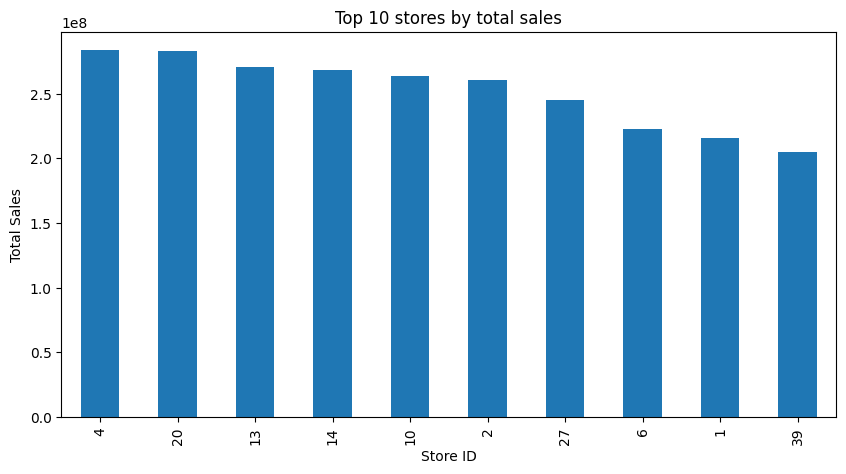

In [21]:
#Top 10 stores by sales performance#
store_sales = df.groupby("Store")["Weekly_Sales"].sum()
top_10_stores = store_sales.sort_values(ascending = False).head(10)
plt.figure(figsize=(10, 5))
top_10_stores.plot(kind="bar")
#sns.barplot(x=top_10_stores.index, y=top_10_stores.values, palette="viridis")
plt.title("Top 10 stores by total sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.show()

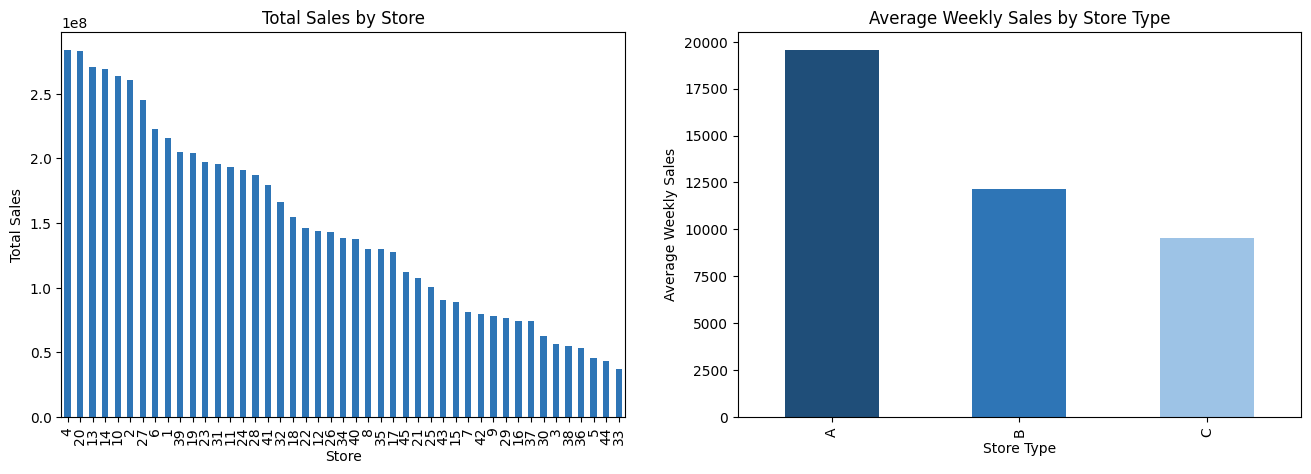

In [22]:
#Total sales per store, sorted
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# Left: Bar chart of total sales by store
store_sales.plot(kind="bar", ax=axes[0], color="#2E75B6")
axes[0].set_title("Total Sales by Store")
axes[0].set_xlabel("Store")
axes[0].set_ylabel("Total Sales")
 
# Right: Average sales by store type
type_sales = df.groupby("Type")["Weekly_Sales"].mean().sort_values(ascending=False)
bars = type_sales.plot(kind="bar", ax=axes[1], color=["#1F4E79","#2E75B6","#9DC3E6"])
axes[1].set_title("Average Weekly Sales by Store Type")
axes[1].set_xlabel("Store Type")
axes[1].set_ylabel("Average Weekly Sales")
plt.show()

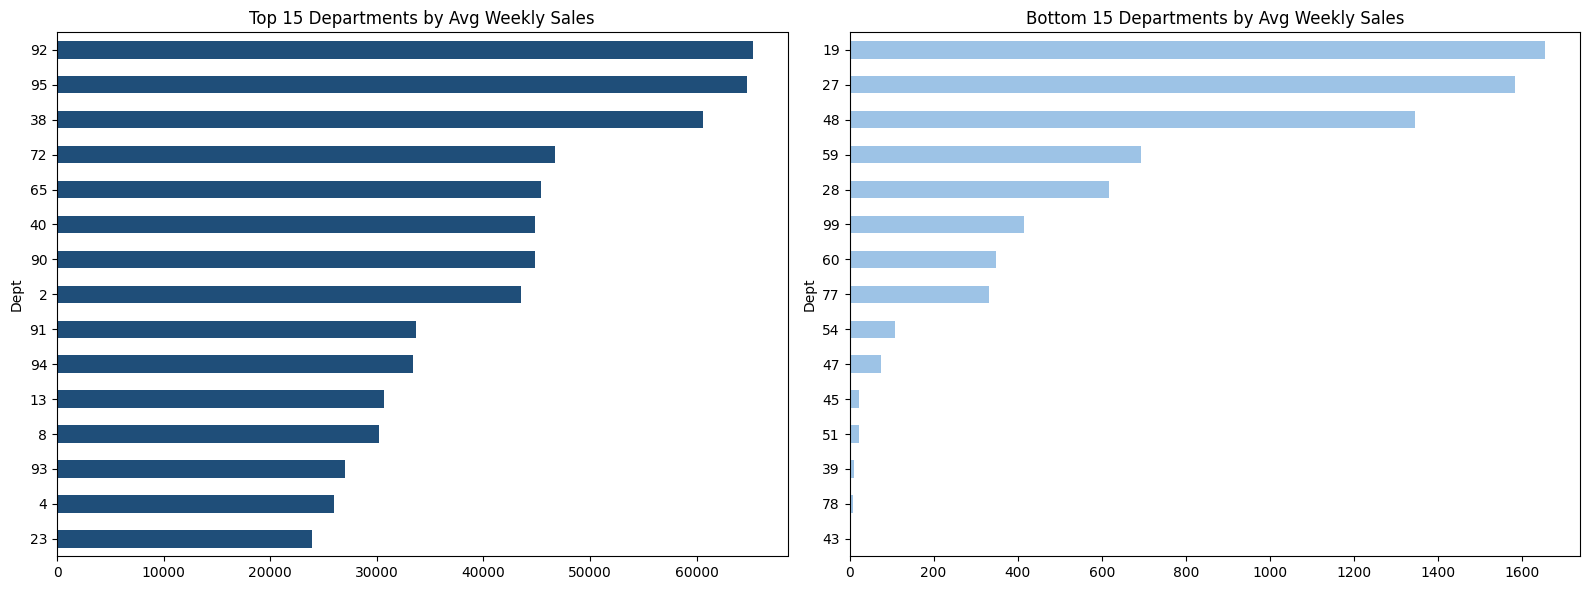

In [23]:
#Top 15 and Bottom 15 departments by average weekly sales ─
dept_sales = df.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
dept_sales.head(15).plot(kind="barh", ax=axes[0], color="#1F4E79")
axes[0].set_title('Top 15 Departments by Avg Weekly Sales')
axes[0].invert_yaxis()
 
dept_sales.tail(15).plot(kind="barh", ax=axes[1], color="#9DC3E6")
axes[1].set_title("Bottom 15 Departments by Avg Weekly Sales")
axes[1].invert_yaxis()
 
plt.tight_layout()
#plt.savefig("dashboard/dept_performance.png", dpi=150, bbox_inches="tight")
plt.show()

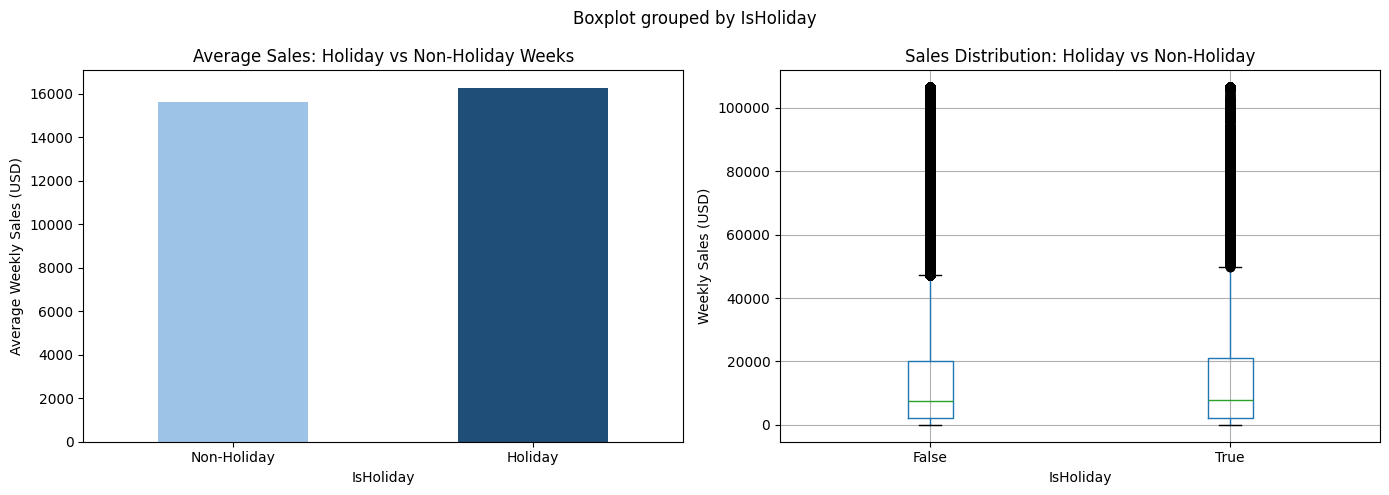

In [24]:
#Compare sales on holiday vs non holiday weeks
holiday_comparison = df.groupby("IsHoliday")["Weekly_Sales"].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Bar chart
holiday_comparison.plot(kind="bar", ax=axes[0], color=["#9DC3E6","#1F4E79"])
axes[0].set_title("Average Sales: Holiday vs Non-Holiday Weeks")
axes[0].set_xticklabels(["Non-Holiday","Holiday"], rotation=0)
axes[0].set_ylabel("Average Weekly Sales (USD)")
 
# Box plot to show the spread
df.boxplot(column="Weekly_Sales", by="IsHoliday", ax=axes[1])
axes[1].set_title("Sales Distribution: Holiday vs Non-Holiday")
axes[1].set_xlabel("IsHoliday")
axes[1].set_ylabel("Weekly Sales (USD)")
 
plt.tight_layout()
#plt.savefig("dashboard/holiday_effect.png", dpi=150, bbox_inches="tight")
plt.show()

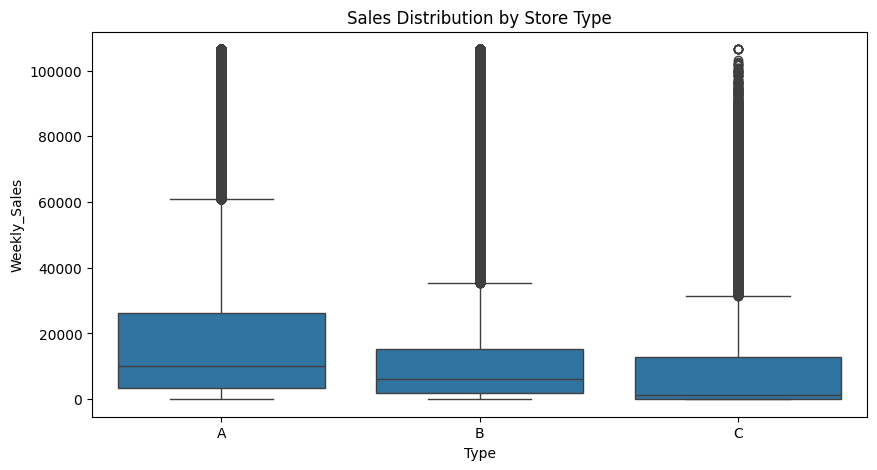

In [25]:
#sales distribution by store type
plt.figure(figsize=(10, 5))
sns.boxplot(x="Type", y="Weekly_Sales", data=df)
plt.title("Sales Distribution by Store Type")
plt.show()

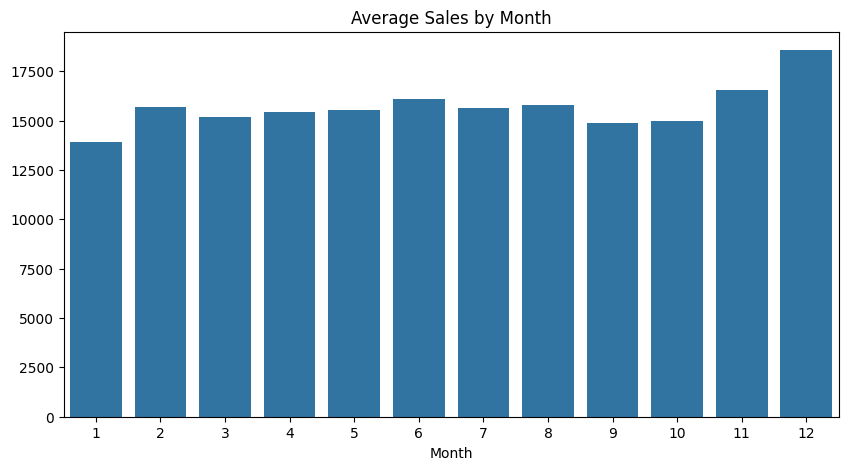

In [26]:
#Average sales by month
plt.figure(figsize=(10, 5))
monthly_sales = df.groupby("Month")["Weekly_Sales"].mean()
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Average Sales by Month")
plt.show()

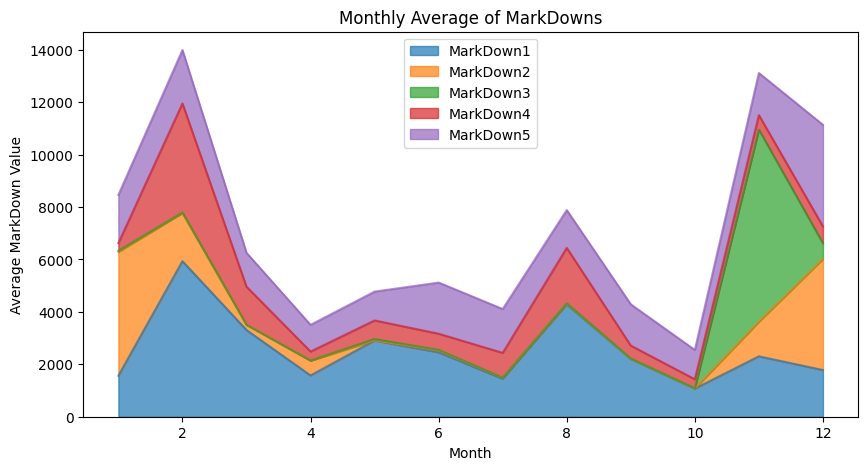

In [27]:
#Monthly average of markdowns to see their trends
markdowns = df.groupby("Month")[markdown_cols].mean()
markdowns.plot(kind = "area", stacked=True, figsize=(10, 5), alpha=0.7)  
plt.title("Monthly Average of MarkDowns")
plt.xlabel("Month")
plt.ylabel("Average MarkDown Value")
plt.legend()
plt.show()

In [28]:
#Holiday impact
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].mean()
print(holiday_sales)

IsHoliday
False    15609.209408
True     16252.946129
Name: Weekly_Sales, dtype: float64


In [29]:
#Holiday impact
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].median()
print(holiday_sales)

IsHoliday
False    7589.95
True     7947.74
Name: Weekly_Sales, dtype: float64


Feature Engineering

In [30]:
#Adding lag features
df = df.sort_values(["Store", "Dept", "Date"])
df["lag_1w"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
df["lag_4w"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)
df["lag_52w"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(52)
df[["lag_1w", "lag_4w", "lag_52w"]] = df[["lag_1w", "lag_4w", "lag_52w"]].fillna(0)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Size,Year,Quarter,Month,Week,Day,Is_Holiday_Season,lag_1w,lag_4w,lag_52w
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,151315,2010,1,2,5,5,0,0.00,0.0,0.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,151315,2010,1,2,6,12,0,24924.50,0.0,0.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,151315,2010,1,2,7,19,0,46039.49,0.0,0.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,151315,2010,1,2,8,26,0,41595.55,0.0,0.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,151315,2010,1,3,9,5,0,19403.54,24924.5,0.0


In [31]:
#Adding rollng avrage features
df["Rolling_4W_Mean"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(window=4).mean()
df["Rolling_12W_Mean"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(window=12).mean()
df[["Rolling_4W_Mean", "Rolling_12W_Mean"]] = df[["Rolling_4W_Mean", "Rolling_12W_Mean"]].fillna(0)

In [32]:
#Adding total markdown feature
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
df["Total_MarkDown"] = df[markdown_cols].sum(axis=1)

In [33]:
#Handling data type
df["Type"] = df["Type"].replace({"A": 1, "B": 2, "C": 3})
df["IsHoliday"] = df["IsHoliday"].astype(int)

C:\Users\asus\AppData\Local\Temp\ipykernel_17924\935255312.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Type"] = df["Type"].replace({"A": 1, "B": 2, "C": 3})


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Store              421570 non-null  int64         
 1   Dept               421570 non-null  int64         
 2   Date               421570 non-null  datetime64[ns]
 3   Weekly_Sales       421570 non-null  float64       
 4   IsHoliday          421570 non-null  int64         
 5   Temperature        421570 non-null  float64       
 6   Fuel_Price         421570 non-null  float64       
 7   MarkDown1          421570 non-null  float64       
 8   MarkDown2          421570 non-null  float64       
 9   MarkDown3          421570 non-null  float64       
 10  MarkDown4          421570 non-null  float64       
 11  MarkDown5          421570 non-null  float64       
 12  CPI                421570 non-null  float64       
 13  Unemployment       421570 non-null  float64 

In [35]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Month,Week,Day,Is_Holiday_Season,lag_1w,lag_4w,lag_52w,Rolling_4W_Mean,Rolling_12W_Mean,Total_MarkDown
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.00,0.00,0.00,...,2,5,5,0,0.00,0.00,0.00,0.0000,0.000000,0.00
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.00,0.00,0.00,...,2,6,12,0,24924.50,0.00,0.00,0.0000,0.000000,0.00
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.00,0.00,0.00,...,2,7,19,0,46039.49,0.00,0.00,0.0000,0.000000,0.00
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.00,0.00,0.00,...,2,8,26,0,41595.55,0.00,0.00,0.0000,0.000000,0.00
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.00,0.00,0.00,...,3,9,5,0,19403.54,24924.50,0.00,32990.7700,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,0,64.88,3.997,4556.61,20.64,1.50,...,9,39,28,0,467.30,346.04,727.05,442.9350,565.753333,9468.01
421566,45,98,2012-10-05,628.10,0,64.89,3.985,5046.74,0.00,18.82,...,10,40,5,0,508.37,352.44,894.98,483.5175,553.146667,9659.00
421567,45,98,2012-10-12,1061.02,0,54.47,4.000,1956.28,0.00,7.89,...,10,41,12,0,628.10,605.96,996.40,552.4325,547.554167,6554.03
421568,45,98,2012-10-19,760.01,0,56.47,3.969,2004.02,0.00,3.18,...,10,42,19,0,1061.02,467.30,1058.84,666.1975,565.530833,3982.42


In [36]:
#Final check of dataset before modeling
print("Columns in final dataset:", df.columns)
print("Shape of final dataset:", df.shape)

Columns in final dataset: Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Quarter',
       'Month', 'Week', 'Day', 'Is_Holiday_Season', 'lag_1w', 'lag_4w',
       'lag_52w', 'Rolling_4W_Mean', 'Rolling_12W_Mean', 'Total_MarkDown'],
      dtype='object')
Shape of final dataset: (421570, 28)


In [37]:
#Saving the final dataset
df.to_csv("walmart_processed_data.csv", index=False)
print("File saved")

File saved
